<a href="https://colab.research.google.com/github/harshitmogre/ai-learning-assistant/blob/main/Simple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
# Import Required Libraries :

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

   YearsExperience  Salary
0              0.6   47658
1              0.8   39761
2              0.8   22000
3              0.8   40863
4              0.9   40501
Number of rows: 200
Number of columns: 2
Missing values:
YearsExperience    0
Salary             0
dtype: int64
Statistical Information:
       YearsExperience         Salary
count       200.000000     200.000000
mean          7.658000   91379.005000
std           4.094921   34773.708574
min           0.600000   22000.000000
25%           4.150000   62124.750000
50%           7.450000   91550.000000
75%          11.325000  123118.500000
max          14.900000  159138.000000


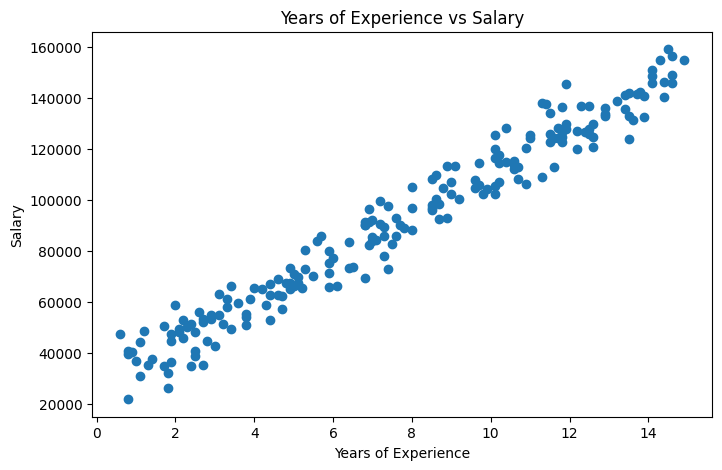

In [5]:
# Part A — Data Loading and Exploration

# 1. Load the dataset using Pandas :
df = pd.read_csv("/content/simple_linear_regression_dataset.csv")

# 2. Display the first five records :
print(df.head());

# 3. Display the number of rows and columns :
print("Number of rows:", df.shape[0]);
print("Number of columns:", df.shape[1]);

# 4. Check for missing values :
print("Missing values:");
print(df.isnull().sum());

# 5. Display basic statistical information :
print("Statistical Information:");
print(df.describe());

# 6. Plot a scatter plot of :

plt.figure(figsize=(8, 5));

plt.scatter( df["YearsExperience"], df["Salary"] );

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")

plt.show()


In [8]:
# Part B — Train-Test Split :

# Seperate X and Y :

X=df['YearsExperience'];
Y=df['Salary'];

X_train , X_test , Y_train , Y_test=train_test_split(X, Y, test_size=0.20 , random_state=42);

In [ ]:
# Part C — Simple Linear Regression using OLS :

x_mean=np.mean(X_train);
y_mean=np.mean(Y_train);

n = np.sum((X_train-x_mean)*(Y_train-y_mean));
d = np.sum((X_train-x_mean)**2);

w = n/d;

b = y_mean - w * x_mean;

print(w,b); print();

print(f"Salary = {w} * YearsExperience + b"); print();

# function for Prediction :
def predict(w , b, x):
  return w * x + b;

# Generate predictions for the training data :
print(predict(w,b,X_train)); print();


# Generate predictions for the testing data :
print(predict(w,b,X_test)); print();




In [15]:
# Part D — Simple Linear Regression using Gradient Descent



#  First we do Standarization :

X_mean_gd = np.mean(X_train);
X_std_gd = np.mean(X_train);

Y_mean_gd = np.mean(Y_train);
Y_std_gd = np.mean(Y_train);

X_train_scaled = (X_train - X_mean_gd) / X_std_gd ;
Y_train_scaled = (Y_train - Y_mean_gd) / Y_std_gd ;



# Initial Values :

w = 0.0;
b = 0.0;
alpha = 0.01;
cost_history=[];


# number of iteration : 1000
n=1000;

# Iteration for 1000 times :
for i in range(int(n)):

  y_predict = b + w * X_train_scaled;

  error = y_predict - Y_train_scaled;

  cost = np.mean(error);

  cost_history.append(cost);

  # Derivative :

  dj_div_dw = np.mean(error * X_train_scaled);
  dj_div_db = np.mean(error);

  # Updating :

  w = w - alpha * dj_div_dw;
  b = b - alpha * dj_div_db;

print(w,b); print();
print(cost_history); print();
print(f"Salary = {w} * YearsExperience + {b}"); print();

0.6624172370724517 -4.6525283625697763e-17

[np.float64(-1.3877787807814458e-18), np.float64(-4.163336342344337e-18), np.float64(-2.7755575615628915e-18), np.float64(0.0), np.float64(-9.714451465470119e-18), np.float64(-1.3877787807814458e-18), np.float64(-6.938893903907228e-18), np.float64(4.163336342344337e-18), np.float64(5.551115123125783e-18), np.float64(4.163336342344337e-18), np.float64(-4.163336342344337e-18), np.float64(5.551115123125783e-18), np.float64(5.551115123125783e-18), np.float64(2.7755575615628915e-18), np.float64(2.7755575615628915e-18), np.float64(-1.3877787807814458e-18), np.float64(-2.7755575615628915e-18), np.float64(-2.7755575615628915e-18), np.float64(8.326672684688674e-18), np.float64(-1.3877787807814458e-18), np.float64(5.551115123125783e-18), np.float64(-2.7755575615628915e-18), np.float64(1.3877787807814458e-18), np.float64(2.7755575615628915e-18), np.float64(0.0), np.float64(0.0), np.float64(1.1102230246251566e-17), np.float64(2.7755575615628915e-18), np.

In [ ]:
# Part E — Model Evaluation :


# Convert coefficients to original scale
w_original = ( w * Y_std_gd / X_std_gd );

b_original = ( Y_mean_gd + Y_std_gd * b - w_original * X_mean_gd );

print(f"Original w is : {w_original}");
print(f"Original b is : {b_original}");

# Pridiction :
print("Prediction : ");
print(predict(w_original,b_original,X_test)); print();
print(predict(w_original,b_original,X_train)); print();



# MSE Function :

def calculate_mse(y_actual, y_predicted):
    return np.mean( (y_actual - y_predicted) ** 2 );

# RMSE Function :

def calculate_rmse(y_actual, y_predicted):
    mse = calculate_mse( y_actual, y_predicted);
    return np.sqrt(mse);

# MAE Function :

def calculate_mae(y_actual, y_predicted):
    return np.mean( np.abs(y_actual - y_predicted));

# R² Function :

def calculate_r2(y_actual, y_predicted):

    ss_total = np.sum( (y_actual - np.mean(y_actual)) ** 2 );
    ss_residual = np.sum( (y_actual - y_predicted) ** 2 );
    return 1 - (ss_residual / ss_total);






ols_mse = calculate_mse( Y_test, b_original );

ols_rmse = calculate_rmse( Y_test, b_original );

ols_mae = calculate_mae( Y_test, b_original );

ols_r2 = calculate_r2( Y_test, b_original )

print("OLS Performance")
print("-------------------------")
print("Test MSE :", ols_mse)
print("Test RMSE:", ols_rmse)
print("Test MAE :", ols_mae)
print("Test R²  :", ols_r2)

In [ ]:
# Part F — Visualization :


# OLS REGRESSION LINE :


x_line = np.linspace(
    X.min(),
    X.max(),
    100
)

y_line_ols = predict(
    beta0_ols,
    beta1_ols,
    x_line
)

plt.figure(figsize=(8, 5))

plt.scatter(
    X_train,
    y_train,
    label="Training Data"
)

plt.scatter(
    X_test,
    y_test,
    label="Testing Data"
)

plt.plot(
    x_line,
    y_line_ols,
    label="OLS Regression Line"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("OLS Regression Line")
plt.legend()

plt.show()



# GRADIENT DESCENT REGRESSION LINE :


y_line_gd = predict(
    beta0_gd_original,
    beta1_gd_original,
    x_line
)

plt.figure(figsize=(8, 5))

plt.scatter(
    X_train,
    y_train,
    label="Training Data"
)

plt.scatter(
    X_test,
    y_test,
    label="Testing Data"
)

plt.plot(
    x_line,
    y_line_gd,
    label="Gradient Descent Regression Line"
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Gradient Descent Regression Line")
plt.legend()

plt.show()



# COST VS ITERATIONS :


plt.figure(figsize=(8, 5))

plt.plot(
    range(1, iterations + 1),
    cost_history
)

plt.xlabel("Iteration")
plt.ylabel("Cost / MSE")
plt.title("Gradient Descent Cost vs Iterations")

plt.show()

In [ ]:
# PART G — COMPARISON :


comparison = pd.DataFrame({

    "Metric": [
        "Intercept",
        "Slope",
        "Test MSE",
        "Test RMSE",
        "Test MAE",
        "Test R²"
    ],

    "OLS": [
        beta0_ols,
        beta1_ols,
        ols_mse,
        ols_rmse,
        ols_mae,
        ols_r2
    ],

    "Gradient Descent": [
        beta0_gd_original,
        beta1_gd_original,
        gd_mse,
        gd_rmse,
        gd_mae,
        gd_r2
    ]
})

print("\n========== OLS vs GRADIENT DESCENT ==========")
print(comparison)